In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('/content/sample_data/drug200.csv')
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [3]:
df['Drug'].unique()

array(['DrugY', 'drugC', 'drugX', 'drugA', 'drugB'], dtype=object)

In [4]:
df.isnull().sum().sum()

np.int64(0)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


### Data Analysis and Visualization

Let's analyze the distribution of numerical features: `Age` and `Na_to_K`.

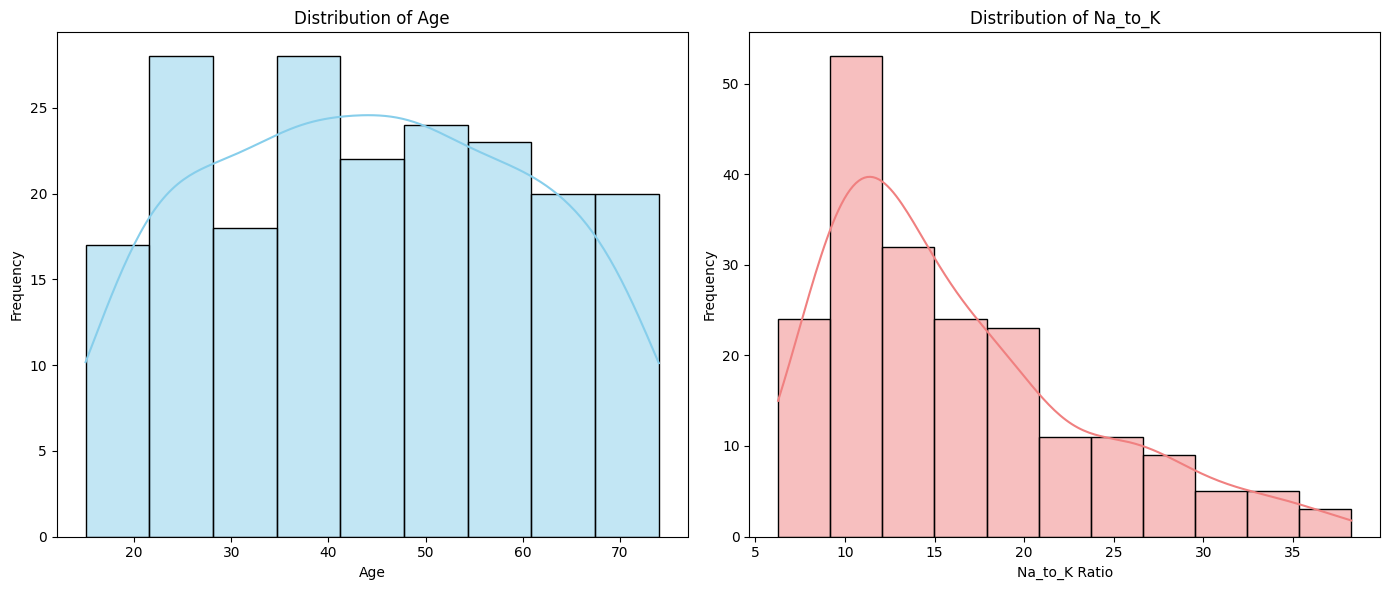


Descriptive statistics for numerical features:


,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [7]:
# Plot distributions of numerical features
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

sns.histplot(df['Na_to_K'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Na_to_K')
axes[1].set_xlabel('Na_to_K Ratio')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\nDescriptive statistics for numerical features:")
display(df[['Age', 'Na_to_K']].describe())

Next, let's look at the distributions of the categorical features: `Sex`, `BP`, `Cholesterol`, and `Drug` (the target variable).

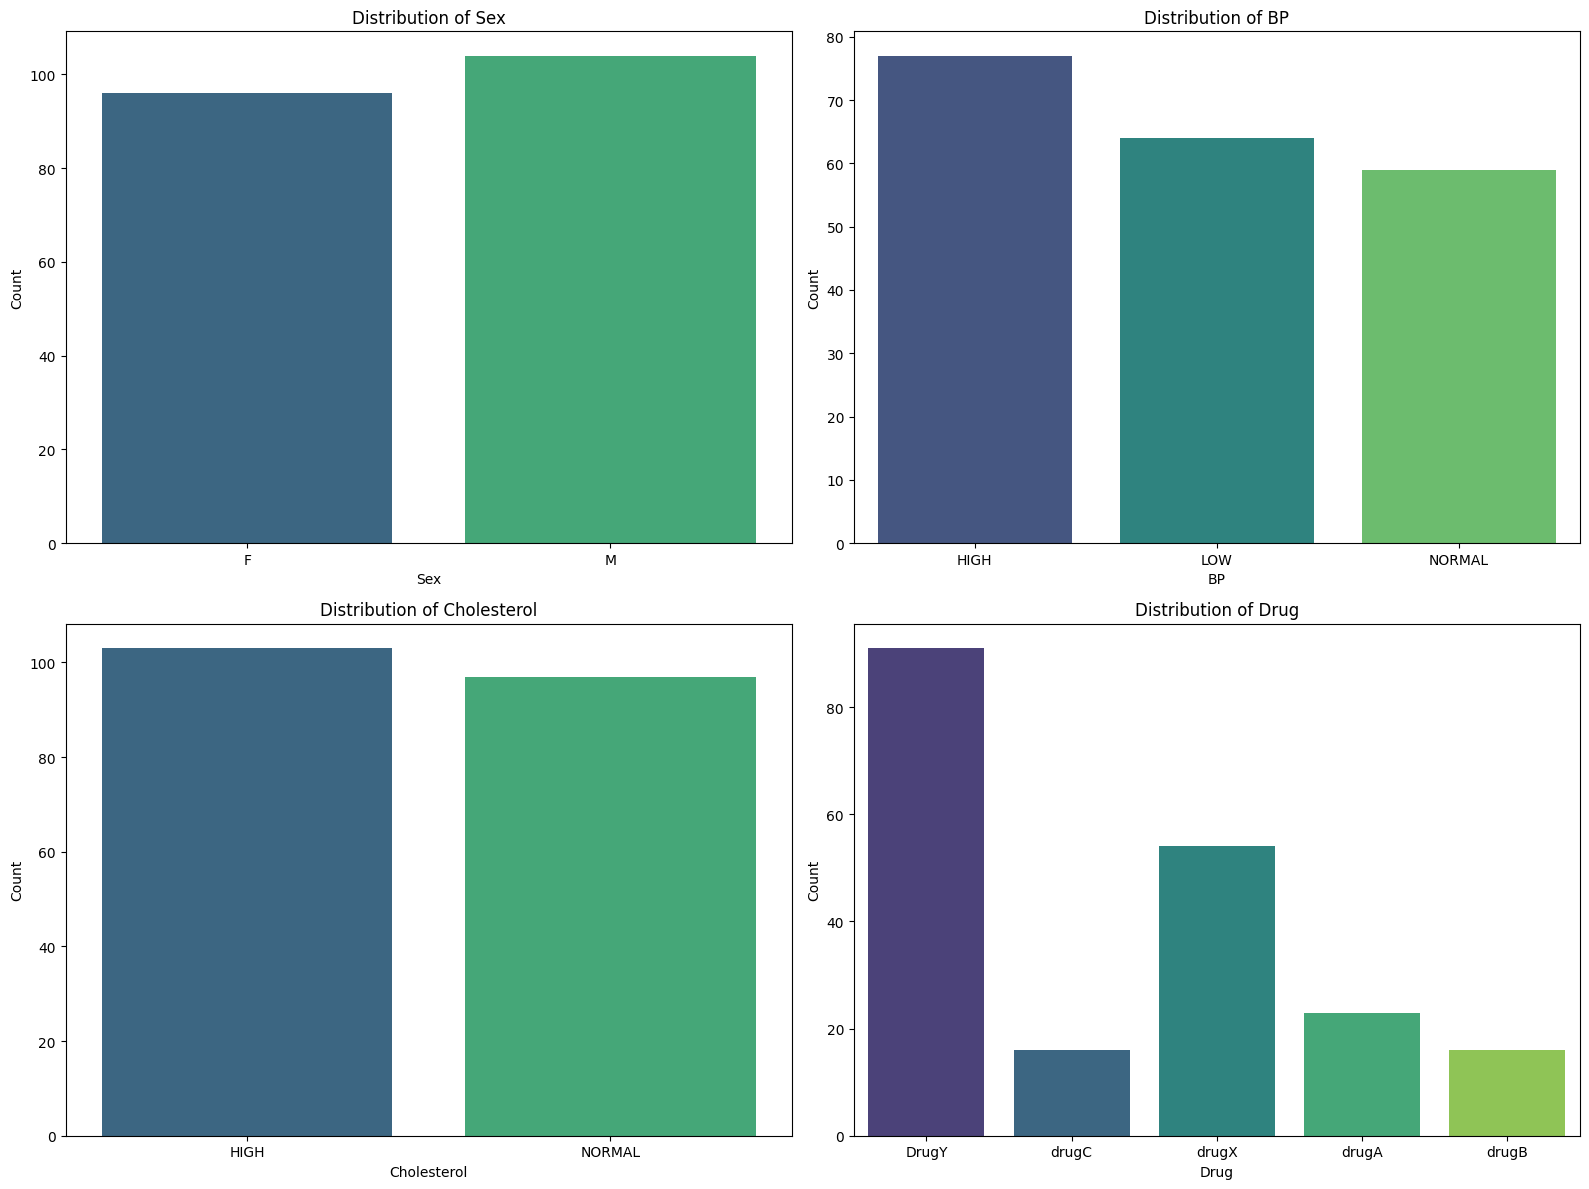


Value counts for categorical features:

--- Sex ---


,count
Sex,
M,104
F,96



--- BP ---


,count
BP,
HIGH,77
LOW,64
NORMAL,59



--- Cholesterol ---


,count
Cholesterol,
HIGH,103
NORMAL,97



--- Drug ---


,count
Drug,
DrugY,91
drugX,54
drugA,23
drugC,16
drugB,16


In [8]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

categorical_cols = ['Sex', 'BP', 'Cholesterol', 'Drug']

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i], palette='viridis', hue=col, legend=False)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("\nValue counts for categorical features:")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(df[col].value_counts())

In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [10]:
X = df.drop(['Drug'], axis= 1)
y = df['Drug']

In [11]:
X

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,F,HIGH,HIGH,25.355
1,47,M,LOW,HIGH,13.093
2,47,M,LOW,HIGH,10.114
3,28,F,NORMAL,HIGH,7.798
4,61,F,LOW,HIGH,18.043
...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567
196,16,M,LOW,HIGH,12.006
197,52,M,NORMAL,HIGH,9.894
198,23,M,NORMAL,NORMAL,14.020


In [12]:
y

,Drug
0,DrugY
1,drugC
2,drugC
3,drugX
4,DrugY
...,...
195,drugC
196,drugC
197,drugX
198,drugX


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.20, random_state=42)

In [17]:
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,0
1,47,1,1,0,13.093,3
2,47,1,1,0,10.114,3
3,28,0,2,0,7.798,4
4,61,0,1,0,18.043,0
...,...,...,...,...,...,...
195,56,0,1,0,11.567,3
196,16,1,1,0,12.006,3
197,52,1,2,0,9.894,4
198,23,1,2,1,14.020,4


In [40]:
encoder = LabelEncoder()
sc =  StandardScaler()

categorical_cols_in_X = X_train.select_dtypes(include='object').columns
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# Apply LabelEncoder to each categorical column in both train and test sets
for col in categorical_cols_in_X:
    X_train_processed[col] = encoder.fit_transform(X_train_processed[col])
    X_test_processed[col] = encoder.transform(X_test_processed[col]) # Use transform for test set

# Now that all features are numerical, apply StandardScaler
X_train_scaled = sc.fit_transform(X_train_processed)
X_test_scaled = sc.transform(X_test_processed)
# Convert back to DataFrames for easier inspection if needed
X_train_scaled= pd.DataFrame(X_train_scaled, columns=X_train_processed.columns, index=X_train_processed.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_processed.columns, index=X_test_processed.index)

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)
display(X_train_scaled.head())

Shape of X_train_scaled: (160, 5)
Shape of X_test_scaled: (40, 5)


,Age,Sex,BP,Cholesterol,Na_to_K
79,-0.834056,-1.038230,0.082083,1.105542,-0.740459
197,0.411966,0.963177,1.276013,-0.904534,-0.871267
38,-0.397948,-1.038230,1.276013,1.105542,-0.896848
24,-0.771755,-1.038230,0.082083,-0.904534,2.390909
122,-0.709454,0.963177,1.276013,-0.904534,0.865739


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import  classification_report , accuracy_score

In [42]:
lo =  LogisticRegression()

In [43]:
model = lo.fit(X_train_scaled , y_train)
model

LogisticRegression()

In [44]:
y_pred  = model.predict(X_test_scaled)

In [48]:
print(classification_report(y_pred , y_test))
print('Model ACC was  : ',accuracy_score(y_pred , y_test))

              precision    recall  f1-score   support

       DrugY       0.93      0.88      0.90        16
       drugA       1.00      0.86      0.92         7
       drugB       1.00      1.00      1.00         3
       drugC       0.80      1.00      0.89         4
       drugX       0.91      1.00      0.95        10

    accuracy                           0.93        40
   macro avg       0.93      0.95      0.93        40
weighted avg       0.93      0.93      0.92        40

Model ACC was  :  0.925


### Model Evaluation: Confusion Matrix

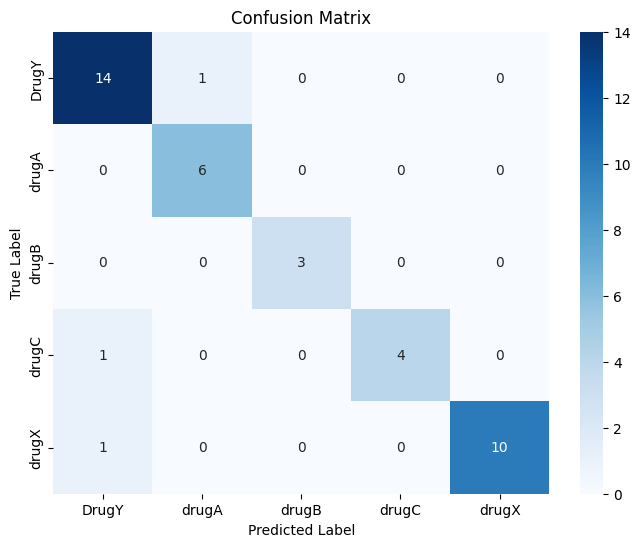


Classification Report:
              precision    recall  f1-score   support

       DrugY       0.88      0.93      0.90        15
       drugA       0.86      1.00      0.92         6
       drugB       1.00      1.00      1.00         3
       drugC       1.00      0.80      0.89         5
       drugX       1.00      0.91      0.95        11

    accuracy                           0.93        40
   macro avg       0.95      0.93      0.93        40
weighted avg       0.93      0.93      0.93        40



In [50]:
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get unique class names for labels
class_names = np.unique(y_test)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

The confusion matrix visually represents the model's performance. The diagonal elements show the number of correct predictions for each drug type, while off-diagonal elements indicate misclassifications. For example, a high value on the diagonal for 'DrugY' means the model accurately predicted 'DrugY' many times.

The classification report provides a detailed breakdown of precision, recall, and f1-score for each drug type, along with overall accuracy.